# Stage 6 — Inference на произвольном mp4

Пайплайн:
1. yt-dlp качает видео (≤60 с), сэмплируем 1 кадр/сек
2. Прогоняем каждый кадр через Inception-v3 + YT8M PCA → **1024-мерный** вектор на кадр
3. Аудио: в `feature_extractor.extract_audio_features` реального VGGish нет — отдаёт нули. Для наших моделей это нормально (в stage 3 мы тренировались с `drop_audio_p=0.1`, модель умеет работать без аудио)
4. Получаем `(T, 1024)` rgb + `(T, 128)` audio, падим/обрезаем до `L`, нормализуем теми же `norm_stats.npz` из train, прогоняем через модель

В отличие от старого inference здесь **не усредняем** кадры — передаём в модель как последовательность.

In [1]:
# ============================================================
# 6.0 — Импорты, ClearML и конфиг
# ============================================================
import sys, json, subprocess
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import cv2
import warnings

warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve() / 'scripts'))
import feature_extractor as yt8m_fe

# ── ClearML: inference — отдельный тип задачи, чтобы в UI можно было
#    фильтровать "на чём инферили".
from clearml import Task, Dataset as ClearMLDataset
task = Task.init(
    project_name="Video Classifier",
    task_name="06_inference",
    task_type=Task.TaskTypes.inference,
    reuse_last_task_id=False,
)

# ── Данные: берём нормализационные статистики из yt8m-frame-splits
#    (а сами веса подгружаются через Task.get_task из 05_training ниже).
_local_processed = Path('../data/frame_processed')
_local_splits    = Path('../data/frame_stage3')
if _local_processed.exists() and _local_splits.exists():
    SRC_DIR    = _local_processed
    STAGE3_DIR = _local_splits
    print(f'✓ using local: {SRC_DIR}, {STAGE3_DIR}')
else:
    SRC_DIR = Path(ClearMLDataset.get(
        dataset_name="yt8m-frame-processed",
        dataset_project="Video Classifier",
    ).get_local_copy())
    STAGE3_DIR = Path(ClearMLDataset.get(
        dataset_name="yt8m-frame-splits",
        dataset_project="Video Classifier",
    ).get_local_copy())
    print(f'✓ processed: {SRC_DIR}')
    print(f'✓ splits   : {STAGE3_DIR}')

STAGE5_DIR = Path('../data/frame_stage5')
INFER_DIR  = Path('../data/frame_inference'); INFER_DIR.mkdir(exist_ok=True)

cfg_src = json.load(open(SRC_DIR    / 'config.json'))
cfg     = json.load(open(STAGE3_DIR / 'config.json'))
L         = cfg['L']
DIM_RGB   = cfg['dim_rgb']
DIM_AUD   = cfg['dim_audio']
N_CLASSES = cfg['n_classes']
GENRES    = cfg['genres']
DEQ_S     = cfg_src['dequant_scale']
DEQ_B     = cfg_src['dequant_bias']
norm      = np.load(STAGE3_DIR / 'norm_stats.npz')
DEVICE    = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)

infer_params = {
    'L': L, 'n_classes': N_CLASSES, 'genres': GENRES,
    'dim_rgb': DIM_RGB, 'dim_audio': DIM_AUD, 'fps_sample': 1,
}
task.connect(infer_params, name='inference_config')

# ── Подгружаем best_*.pt как артефакты из последней training-задачи.
#    Если нашлось — копируем в STAGE5_DIR (чтобы load_model в cell-2 работал
#    без переписывания). Иначе используем локальные файлы.
try:
    training_task = Task.get_task(
        project_name="Video Classifier",
        task_name="05_training",
    )
    for name in ('best_flatten', 'best_rnn'):
        if name in training_task.artifacts:
            local_pt = training_task.artifacts[name].get_local_copy()
            dst = STAGE5_DIR / f'{name}.pt'
            STAGE5_DIR.mkdir(parents=True, exist_ok=True)
            if Path(local_pt) != dst:
                import shutil; shutil.copy(local_pt, dst)
            print(f'✓ pulled {name} from training task {training_task.id}')
    task.set_user_properties(source_training_task_id=training_task.id)
except Exception as e:
    print(f'⚠ не нашли training-задачу в ClearML ({e}); используем локальные веса')

print(f'L={L}  GENRES={GENRES}  device={DEVICE}')
print(f'ClearML task: {task.id}')

ClearML Task: created new task id=359da013d0ec4cee903b33d30e95f24b
ClearML results page: https://app.clear.ml/projects/f6756b373a194d77b25caf2f40ed8950/experiments/359da013d0ec4cee903b33d30e95f24b/output/log
2026-05-17 14:08:24,508 - clearml.resource_monitor - WARNING - Could not fetch GPU stats: NVML Shared Library Not Found
✓ using local: ../data/frame_processed, ../data/frame_stage3
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
✓ pulled best_flatten from training task 090ee6ee0553472c8e1556c3672ae529
✓ pulled best_rnn from training task 090ee6ee0553472c8e1556c3672ae529
L=60  GENRES=['Animals', 'Animation', 'Beauty', 'Dance', 'Film', 'Food', 'Gaming', 'Music', 'Performance', 'Sports', 'Tech', 'Vehicles']  device=mps
ClearML task: 359da013d0ec4cee903b33d30e95f24b


In [2]:
# ============================================================
# 6.1 — Определения моделей (самодостаточно)
# ============================================================
class FlattenMLP(nn.Module):
    def __init__(self, n_frames, dim_rgb, dim_aud, n_classes,
                 hidden=(1024, 512), dropout=0.4):
        super().__init__()
        self.n_frames = n_frames
        in_dim = n_frames * (dim_rgb + dim_aud)
        layers = []; prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.GELU(), nn.Dropout(dropout)]; prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, rgb, aud, lengths=None):
        K = self.n_frames
        x = torch.cat([rgb[:, :K], aud[:, :K]], dim=-1).reshape(rgb.size(0), -1)
        return self.net(x)


class FrameRNN(nn.Module):
    def __init__(self, dim_rgb, dim_aud, n_classes,
                 proj_dim=256, rnn_hidden=256, rnn_layers=1,
                 bidirectional=True, dropout=0.3, cell='gru'):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(dim_rgb + dim_aud, proj_dim),
                                  nn.LayerNorm(proj_dim), nn.GELU(), nn.Dropout(dropout))
        RNN = {'gru': nn.GRU, 'lstm': nn.LSTM}[cell]
        self.rnn = RNN(proj_dim, rnn_hidden, num_layers=rnn_layers,
                       batch_first=True, bidirectional=bidirectional,
                       dropout=dropout if rnn_layers > 1 else 0.0)
        out_dim = rnn_hidden * (2 if bidirectional else 1)
        self.head = nn.Sequential(nn.LayerNorm(out_dim), nn.Dropout(dropout),
                                  nn.Linear(out_dim, n_classes))
        self.bi = bidirectional; self.cell = cell

    def forward(self, rgb, aud, lengths):
        x = self.proj(torch.cat([rgb, aud], dim=-1))
        lens_cpu = lengths.detach().cpu().clamp(min=1)
        packed = pack_padded_sequence(x, lens_cpu, batch_first=True, enforce_sorted=False)
        _, h = self.rnn(packed)
        if self.cell == 'lstm': h = h[0]
        h = torch.cat([h[-2], h[-1]], dim=-1) if self.bi else h[-1]
        return self.head(h)


class AudioGateNet(nn.Module):
    def __init__(self, dim_aud, hidden=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_aud, hidden), nn.BatchNorm1d(hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, 64), nn.GELU(), nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def gate(self, audio_seq, lengths, threshold=0.5):
        T = lengths.float().clamp(min=1)
        mask = torch.arange(audio_seq.size(1), device=audio_seq.device).unsqueeze(0) < lengths.unsqueeze(1)
        mean_aud = (audio_seq * mask.unsqueeze(-1)).sum(1) / T.unsqueeze(1)
        with torch.no_grad():
            prob = torch.sigmoid(self.forward(mean_aud))
        return (prob >= threshold).float()


class GatedRNN(nn.Module):
    def __init__(self, dim_rgb, dim_aud, n_classes,
                 proj_dim=256, rnn_hidden=256, rnn_layers=1,
                 bidirectional=True, dropout=0.3, cell='gru'):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(dim_rgb + dim_aud, proj_dim),
                                  nn.LayerNorm(proj_dim), nn.GELU(), nn.Dropout(dropout))
        RNN = {'gru': nn.GRU, 'lstm': nn.LSTM}[cell]
        self.rnn = RNN(proj_dim, rnn_hidden, num_layers=rnn_layers,
                       batch_first=True, bidirectional=bidirectional,
                       dropout=dropout if rnn_layers > 1 else 0.0)
        out_dim = rnn_hidden * (2 if bidirectional else 1) + 1
        self.head = nn.Sequential(nn.LayerNorm(out_dim), nn.Dropout(dropout),
                                  nn.Linear(out_dim, n_classes))
        self.bi = bidirectional; self.cell = cell

    def forward(self, rgb, aud, gate_s, lengths):
        x = self.proj(torch.cat([rgb, aud], dim=-1))
        lens_cpu = lengths.detach().cpu().clamp(min=1)
        packed = pack_padded_sequence(x, lens_cpu, batch_first=True, enforce_sorted=False)
        _, h = self.rnn(packed)
        if self.cell == 'lstm': h = h[0]
        h = torch.cat([h[-2], h[-1]], dim=-1) if self.bi else h[-1]
        h = torch.cat([h, gate_s.unsqueeze(1)], dim=-1)
        return self.head(h)


class CrossModalRNN(nn.Module):
    def __init__(self, dim_rgb, dim_aud, n_classes,
                 proj_dim=256, num_heads=4,
                 rnn_hidden=256, rnn_layers=1, dropout=0.3):
        super().__init__()
        self.proj_rgb = nn.Sequential(
            nn.Linear(dim_rgb, proj_dim), nn.LayerNorm(proj_dim), nn.GELU(),
        )
        self.proj_aud = nn.Sequential(
            nn.Linear(dim_aud, proj_dim), nn.LayerNorm(proj_dim), nn.GELU(),
        )
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=proj_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.attn_norm = nn.LayerNorm(proj_dim)
        self.attn_drop = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            proj_dim, rnn_hidden, num_layers=rnn_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(rnn_hidden * 2), nn.Dropout(dropout),
            nn.Linear(rnn_hidden * 2, n_classes),
        )

    def forward(self, rgb, aud, lengths, mod_dropout_p=0.0):
        B, L, _ = rgb.shape
        if self.training and mod_dropout_p > 0:
            drop_mask = torch.rand(B, 1, 1, device=rgb.device) < mod_dropout_p
            aud = aud.masked_fill(drop_mask, 0.0)
        q = self.proj_rgb(rgb)
        k = self.proj_aud(aud)
        # lengths может прийти на CPU из DataLoader — явно переносим
        pad_mask = torch.arange(L, device=rgb.device).unsqueeze(0) >= lengths.to(rgb.device).unsqueeze(1)
        attended, _ = self.cross_attn(q, k, k, key_padding_mask=pad_mask)
        x = self.attn_norm(q + self.attn_drop(attended))
        lens_cpu = lengths.detach().cpu().clamp(min=1)
        packed = pack_padded_sequence(x, lens_cpu, batch_first=True, enforce_sorted=False)
        _, h = self.rnn(packed)
        h = torch.cat([h[-2], h[-1]], dim=-1)
        return self.head(h)


_gate_net_cache = None

def load_model(kind):
    if kind == 'flatten':
        m = FlattenMLP(min(30, L), DIM_RGB, DIM_AUD, N_CLASSES,
                       hidden=(1024, 512), dropout=0.4)
    elif kind == 'rnn':
        m = FrameRNN(DIM_RGB, DIM_AUD, N_CLASSES,
                     proj_dim=256, rnn_hidden=256, bidirectional=True,
                     dropout=0.3, cell='gru')
    elif kind == 'gated_rnn':
        m = GatedRNN(DIM_RGB, DIM_AUD, N_CLASSES,
                     proj_dim=256, rnn_hidden=256, bidirectional=True,
                     dropout=0.3, cell='gru')
    elif kind == 'cross_modal':
        m = CrossModalRNN(DIM_RGB, DIM_AUD, N_CLASSES,
                          proj_dim=256, num_heads=4, rnn_hidden=256,
                          rnn_layers=1, dropout=0.3)
    else:
        raise ValueError(kind)
    m.load_state_dict(torch.load(STAGE5_DIR / f'best_{kind}.pt', weights_only=True))
    return m.to(DEVICE).eval()


def get_gate_net():
    global _gate_net_cache
    if _gate_net_cache is None:
        m = AudioGateNet(DIM_AUD)
        m.load_state_dict(torch.load(STAGE5_DIR / 'gate_net.pt', weights_only=True))
        _gate_net_cache = m.to(DEVICE).eval()
    return _gate_net_cache

In [3]:
# ============================================================
# 6.2 — Инициализация YT8M-экстрактора (Inception + PCA)
# ============================================================
print('init YT8M feature extractor (первый раз скачает ~100MB)...')
extractor = yt8m_fe.YouTube8MFeatureExtractor()
print('ok')

init YT8M feature extractor (первый раз скачает ~100MB)...


W0000 00:00:1779016114.857056  841771 op_def_util.cc:371] Op BatchNormWithGlobalNormalization is deprecated. It will cease to work in GraphDef version 9. Use tf.nn.batch_normalization().


ok


In [4]:
# ============================================================
# 6.3 — Per-frame экстрактор признаков + predict_genre
# ============================================================
def extract_frame_features(video_path, fps_sample=1, max_frames=None):
    if max_frames is None:
        max_frames = L
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    step = max(int(round(fps / fps_sample)), 1)

    rgb_feats = []
    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok: break
        if frame_idx % step == 0:
            feat = extractor.extract_rgb_frame_features(frame[:, :, ::-1], apply_pca=True)
            rgb_feats.append(feat.astype(np.float32))
            if len(rgb_feats) >= max_frames: break
        frame_idx += 1
    cap.release()
    if not rgb_feats:
        raise RuntimeError(f'Не удалось извлечь кадры из {video_path}')

    rgb_arr = np.stack(rgb_feats, axis=0)
    aud_arr = np.zeros((rgb_arr.shape[0], DIM_AUD), dtype=np.float32)
    return rgb_arr, aud_arr


def prepare_tensors(rgb_arr, aud_arr):
    T = min(rgb_arr.shape[0], L)
    rgb = np.zeros((L, DIM_RGB), dtype=np.float32)
    aud = np.zeros((L, DIM_AUD), dtype=np.float32)
    rgb[:T] = (rgb_arr[:T] - norm['rgb_mean']) / norm['rgb_std']
    aud[:T] = (aud_arr[:T] - norm['aud_mean']) / norm['aud_std']
    return (torch.from_numpy(rgb).unsqueeze(0).to(DEVICE),
            torch.from_numpy(aud).unsqueeze(0).to(DEVICE),
            torch.tensor([T], dtype=torch.long).to(DEVICE))


def predict_genre(video_path, top_k=5, variant='rnn'):
    model = load_model(variant)
    rgb_arr, aud_arr = extract_frame_features(video_path, fps_sample=1, max_frames=L)
    print(f'extracted {rgb_arr.shape[0]} frames')
    rgb, aud, lens = prepare_tensors(rgb_arr, aud_arr)

    with torch.no_grad():
        if variant == 'gated_rnn':
            gate_model = get_gate_net()
            gate_s = gate_model.gate(aud, lens)          # (1,) ∈ {0., 1.}
            aud_gated = aud * gate_s.view(-1, 1, 1)
            logits = model(rgb, aud_gated, gate_s, lens)
            print(f'  gate={gate_s.item():.0f} → audio {"used" if gate_s.item() > 0.5 else "ignored"}')
        else:
            logits = model(rgb, aud, lens)
        probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()

    top = np.argsort(probs)[::-1][:top_k]
    print(f'\nPredictions [{variant}]:')
    for i in top:
        print(f'  {GENRES[i]:<14} {probs[i]*100:>5.1f}%')
    return [(GENRES[i], float(probs[i])) for i in top]


In [5]:
# ============================================================
# 6.4 — Скачивание с YouTube (опционально)
# ============================================================
# Тонкости:
# 1) yt-dlp требует JS-рантайм (ставим node через --js-runtimes).
# 2) Для shorts YouTube часто отдаёт av1/opus в webm/mkv — OpenCV без
#    hw-acc такое не декодит. Форсим h264 через vcodec^=avc1 +
#    merge-output-format mp4. Финальный --recode-video mp4 как страховка.
# 3) Итоговый путь берём из --print after_move:filepath, чтобы не
#    гадать по расширению.
import shutil
JS_RUNTIME = None
for name in ('deno', 'node', 'bun'):
    p = shutil.which(name)
    if p:
        JS_RUNTIME = f'{name}:{p}'
        break
print(f'js-runtime: {JS_RUNTIME or "none — yt-dlp будет ругаться"}')


def download_youtube(url, max_seconds=60):
    out_template = str(INFER_DIR / '%(id)s.%(ext)s')
    fmt = ('bv*[vcodec^=avc1][height<=720]+ba/'
           'b[vcodec^=avc1][height<=720]/'
           'b[height<=720]')
    cmd = ['yt-dlp',
           '-f', fmt,
           '--merge-output-format', 'mp4',
           '--recode-video', 'mp4',
           '--no-playlist', '--no-progress',
           '--download-sections', f'*0-{max_seconds}',
           '--print', 'after_move:filepath',
           '-o', out_template, url]
    if JS_RUNTIME:
        cmd += ['--js-runtimes', JS_RUNTIME]
    res = subprocess.run(cmd, check=True, capture_output=True, text=True)
    lines = [ln for ln in res.stdout.strip().splitlines() if ln.strip()]
    if not lines:
        raise RuntimeError(f'yt-dlp ничего не вывел\nstderr:\n{res.stderr}')
    return Path(lines[-1])

js-runtime: node:/opt/homebrew/bin/node


In [6]:
# ============================================================
# 6.5 — Демо: прогоняем на существующих mp4 из data/inference/
# ============================================================
demo_dir = Path('../data/inference')
for mp4 in sorted(demo_dir.glob('*.mp4')):
    print(f'\n=== {mp4.name} ===')
    for variant in ('flatten', 'rnn', 'gated_rnn'):
        try:
            predict_genre(mp4, top_k=3, variant=variant)
        except Exception as e:
            print(f'  [{variant}] error: {e}')

In [7]:
# ============================================================
# 6.6 — Или скачать новое по ссылке
# ============================================================
urls = [
    'https://youtube.com/shorts/SR77IbxSVug?si=MHAGxpDqxqtjVw3I', # minecraft with words
    'https://youtube.com/shorts/6lj0kAAtZic?si=9rYKmRVTxg3xU0o8', # minecraft without words
    'https://youtube.com/shorts/EEeHld2PRgo?si=3uFNwsV6vWaCWjof', # minecraft edits
    'https://youtube.com/shorts/dKAUBJxPB74?si=vAkzKzX8pgn2iENZ', # random video
]
for YOUTUBE_URL in urls:
    path = download_youtube(YOUTUBE_URL)
    print(f'downloaded: {path}')
    if path:
        for variant in ('rnn', 'gated_rnn', 'flatten'):
            try:
                predict_genre(path, top_k=5, variant=variant)
            except Exception as e:
                print(f'  [{variant}] error: {e}')

downloaded: /Users/rail/Documents/GitHub/video_classifier/data/frame_inference/SR77IbxSVug.mp4


I0000 00:00:1779016124.238481  841771 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


extracted 60 frames

Predictions [rnn]:
  Gaming          98.5%
  Tech             0.5%
  Animation        0.2%
  Sports           0.2%
  Food             0.1%
extracted 60 frames
  gate=0 → audio ignored

Predictions [gated_rnn]:
  Gaming          99.7%
  Tech             0.1%
  Sports           0.1%
  Music            0.0%
  Film             0.0%
extracted 60 frames

Predictions [flatten]:
  Gaming          67.9%
  Sports           5.5%
  Food             4.5%
  Animation        4.5%
  Tech             3.3%
downloaded: /Users/rail/Documents/GitHub/video_classifier/data/frame_inference/6lj0kAAtZic.mp4
2026-05-17 14:09:21,989 - clearml.model - WARNING - Connecting multiple input models with the same name: `best_rnn`. This might result in the wrong model being used when executing remotely
extracted 59 frames

Predictions [rnn]:
  Gaming          98.5%
  Sports           0.3%
  Animation        0.2%
  Beauty           0.2%
  Tech             0.2%
2026-05-17 14:09:30,863 - clearml.model -


Видео для сравнения: 10

── minecraft with words ──
extracted 60 frames

Predictions [flatten]:
  Gaming          67.9%
  Sports           5.5%
  Food             4.5%
  Animation        4.5%
  Tech             3.3%
  Film             2.8%
  Beauty           2.8%
  Dance            2.5%
  Animals          2.3%
  Music            1.7%
  Vehicles         1.4%
  Performance      1.0%
extracted 60 frames

Predictions [rnn]:
  Gaming          98.5%
  Tech             0.5%
  Animation        0.2%
  Sports           0.2%
  Food             0.1%
  Beauty           0.1%
  Film             0.1%
  Music            0.1%
  Dance            0.1%
  Animals          0.0%
  Performance      0.0%
  Vehicles         0.0%
extracted 60 frames
  gate=0 → audio ignored

Predictions [gated_rnn]:
  Gaming          99.7%
  Tech             0.1%
  Sports           0.1%
  Music            0.0%
  Film             0.0%
  Food             0.0%
  Animals          0.0%
  Animation        0.0%
  Performance      0.0%


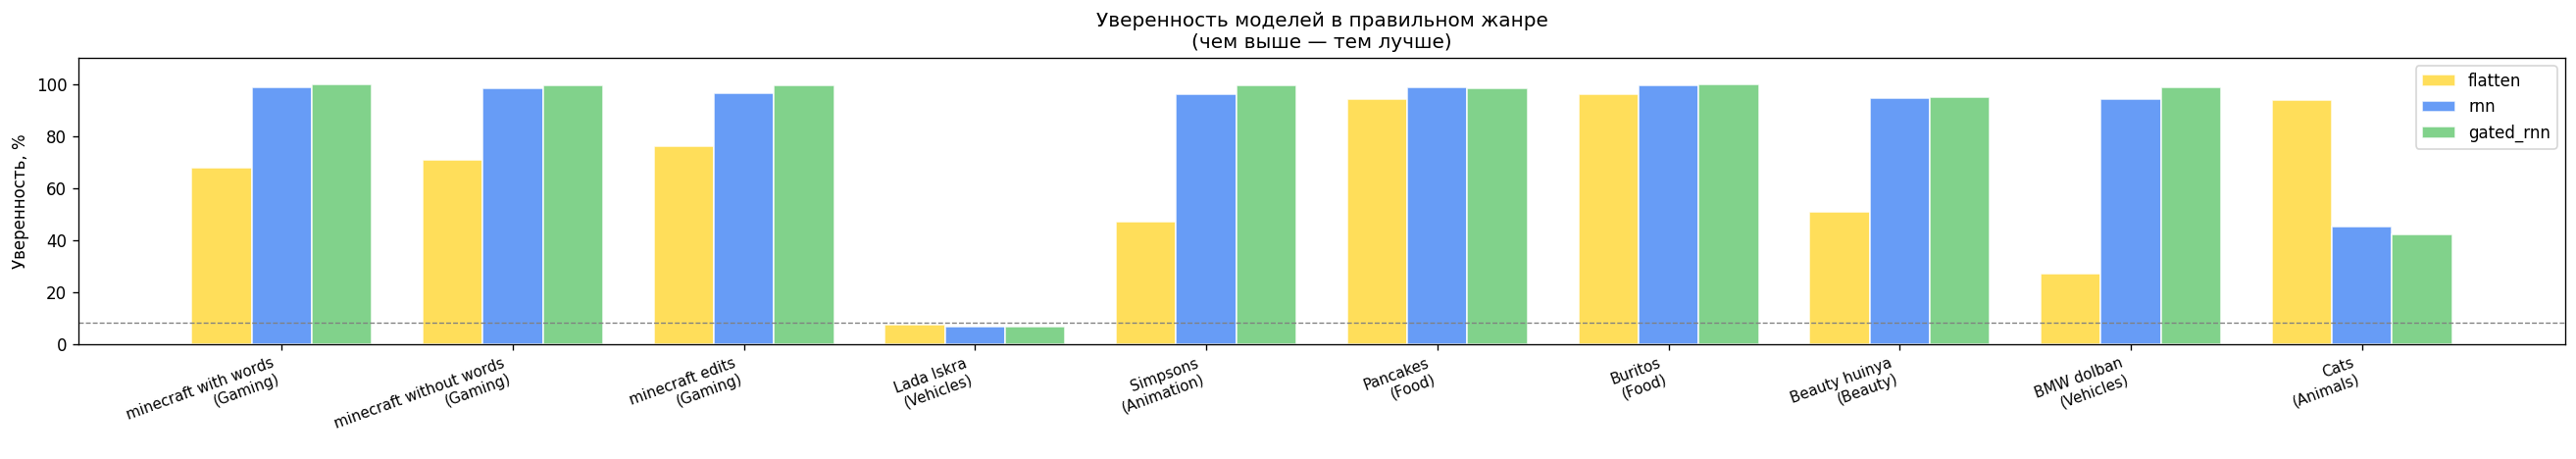

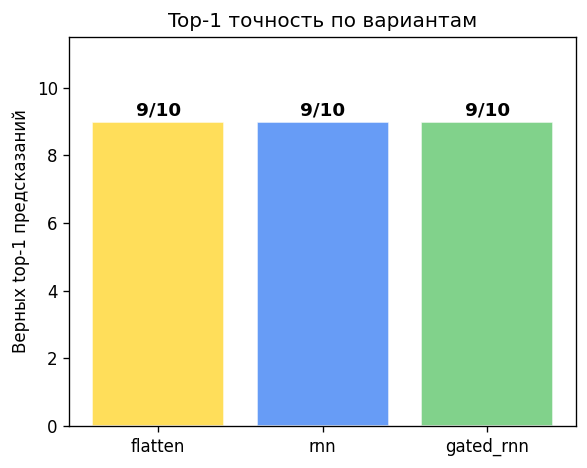

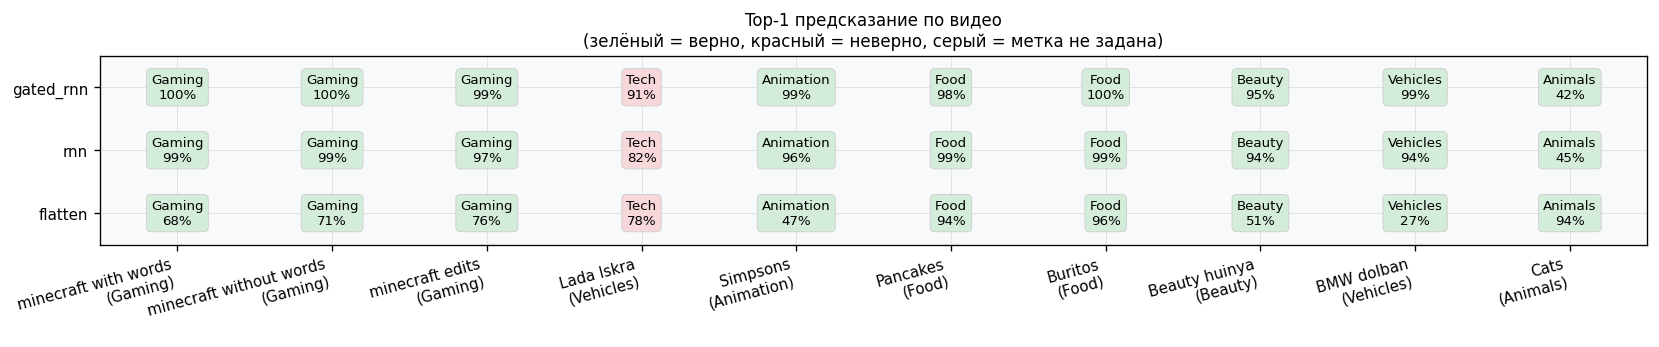


Графики сохранены в ../data/frame_inference


                                          0% | 0.00/137.06 MB [00:00<?, ?MB/s]: 

ClearML Monitor: Reporting detected, reverting back to iteration based reporting


███▎                            11% | 15.00/137.06 MB [00:08<01:11,  1.71MB/s]: Skipping upload, could not find object file '/var/folders/7f/dpfz089j53761_3cq9n2yybh0000gn/T/tmpa_bb_yhe.png'
Skipping upload, could not find object file '/var/folders/7f/dpfz089j53761_3cq9n2yybh0000gn/T/tmp0xitial_.png'
Skipping upload, could not find object file '/var/folders/7f/dpfz089j53761_3cq9n2yybh0000gn/T/tmp3itcpr6e.png'

                                          0% | 0.00/137.06 MB [00:00<?, ?MB/s]: 
████▍                           15% | 20.00/137.06 MB [00:17<02:02,  1.04s/MB]: 
███▎                            11% | 15.00/137.06 MB [00:05<00:46,  2.61MB/s]: 
█████▍                          18% | 25.00/137.06 MB [00:21<01:49,  1.02MB/s]: 
██████▌                         22% | 30.00/137.06 MB [00:25<01:36,  1.11MB/s]: 
████████████                    40% | 55.00/137.06 MB [00:32<00:32,  2.50MB/s]: 
█████████████▏                  44% | 60.00/137.06 MB [00:35<00:36,  2.11MB/s]: 
██████████████▏    

✓ ClearML task closed — id: 359da013d0ec4cee903b33d30e95f24b


In [8]:
# ============================================================
# 6.7 — Сравнительный анализ вариантов моделей
# ============================================================
# Доступные жанры:
#   Animals | Animation | Beauty | Dance | Film | Food |
#   Gaming  | Music     | Performance | Sports | Tech | Vehicles

TEST_VIDEOS = [
    # { 'url': 'https://youtube.com/shorts/...', 'name': 'Название', 'genre': 'Gaming' },
    { 'url': 'https://youtube.com/shorts/SR77IbxSVug?si=MHAGxpDqxqtjVw3I', 'name': 'minecraft with words', 'genre': 'Gaming' },
    { 'url': 'https://youtube.com/shorts/6lj0kAAtZic?si=9rYKmRVTxg3xU0o8', 'name': 'minecraft without words', 'genre': 'Gaming' },
    { 'url': 'https://youtube.com/shorts/EEeHld2PRgo?si=3uFNwsV6vWaCWjof', 'name': 'minecraft edits', 'genre': 'Gaming' },
    { 'url': 'https://youtube.com/shorts/dKAUBJxPB74?si=vAkzKzX8pgn2iENZ', 'name': 'Lada Iskra', 'genre': 'Vehicles' },
    { 'url': 'https://youtube.com/shorts/ecSW1JwlnaU?si=seA-UBXF3p_gN3ac', 'name': 'Simpsons', 'genre': 'Animation' },
    { 'url': 'https://youtube.com/shorts/Pptf7mFAhWM?si=-sucEZJYjjz3xvOK', 'name': 'Pancakes', 'genre': 'Food' },
    { 'url': 'https://youtube.com/shorts/qhhCGVPGDug?si=IOInt707lXNNRuCX', 'name': 'Buritos', 'genre': 'Food' },
    { 'url': 'https://youtube.com/shorts/bvQV-wxXMng?si=7rhZA1v-n6evfaPI', 'name': 'Beauty huinya', 'genre': 'Beauty' },
    { 'url': 'https://youtube.com/shorts/G8RvCt1tBtY?si=pqX_MlkZqEfCoW0C', 'name': 'BMW dolban', 'genre': 'Vehicles' },
    { 'url': 'https://youtube.com/shorts/uH93sKjjfGY?si=KJDkGwD6Bfqwnxih', 'name': 'Cats', 'genre': 'Animals' },
]

# ── Загрузка / переиспользование ──────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
matplotlib.rcParams['figure.dpi'] = 120

VARIANTS = ['flatten', 'rnn', 'gated_rnn']
COLORS   = {'flatten': '#FFD93D', 'rnn': '#4C8BF5', 'gated_rnn': '#6BCB77'}

compare_paths  = []
compare_labels = []
compare_names  = []

if TEST_VIDEOS:
    for v in TEST_VIDEOS:
        try:
            p = download_youtube(v['url'])
            compare_paths.append(p)
            compare_labels.append(v.get('genre'))
            compare_names.append(v.get('name', p.stem))
        except Exception as e:
            print(f'⚠ не скачали {v["name"]}: {e}')
else:
    print('TEST_VIDEOS пустой — берём уже скачанные из INFER_DIR (без правильных меток)')
    compare_paths  = sorted(INFER_DIR.glob('*.mp4'))
    compare_labels = [None] * len(compare_paths)
    compare_names  = [p.stem for p in compare_paths]

print(f'\nВидео для сравнения: {len(compare_paths)}')

# ── Прогон всех вариантов ─────────────────────────────────────────────────────
results = {}  # name → {variant: [(genre, prob), ...]}

for path, name in zip(compare_paths, compare_names):
    results[name] = {}
    print(f'\n── {name} ──')
    for var in VARIANTS:
        try:
            preds = predict_genre(path, top_k=N_CLASSES, variant=var)
            results[name][var] = preds
        except Exception as e:
            results[name][var] = []
            print(f'  [{var}] error: {e}')

# ── График 1: уверенность в правильном жанре ─────────────────────────────────
has_labels = any(lbl is not None for lbl in compare_labels)

fig1, ax1 = plt.subplots(figsize=(max(7, len(compare_paths) * 2.2), 4))
x = np.arange(len(compare_names))
w = 0.26

for i, var in enumerate(VARIANTS):
    confs = []
    for name, lbl in zip(compare_names, compare_labels):
        preds = results[name].get(var, [])
        if lbl and preds:
            conf = next((p for g, p in preds if g == lbl), 0.0)
        elif preds:
            conf = preds[0][1]   # top-1 если метка не задана
        else:
            conf = 0.0
        confs.append(conf * 100)
    bars = ax1.bar(x + i * w - w, confs, w, label=var,
                   color=COLORS[var], alpha=0.85, edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(
    [f'{n}\n({lbl or "?"})' for n, lbl in zip(compare_names, compare_labels)],
    rotation=20, ha='right', fontsize=9,
)
ax1.set_ylabel('Уверенность, %')
ax1.set_title(
    'Уверенность моделей в правильном жанре\n'
    + ('(чем выше — тем лучше)' if has_labels else '(метки не заданы — показан top-1)')
)
ax1.legend()
ax1.set_ylim(0, 110)
ax1.axhline(100 / N_CLASSES, color='grey', linestyle='--', linewidth=0.8, label='random baseline')
plt.tight_layout()
plt.savefig(INFER_DIR / 'compare_confidence.png', dpi=150)
plt.show()

# ── График 2: top-1 точность (только если есть метки) ────────────────────────
if has_labels:
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    correct_counts = {}
    for var in VARIANTS:
        cnt = total = 0
        for name, lbl in zip(compare_names, compare_labels):
            if lbl is None:
                continue
            preds = results[name].get(var, [])
            if preds and preds[0][0] == lbl:
                cnt += 1
            total += 1
        correct_counts[var] = (cnt, total)

    bars = ax2.bar(
        list(correct_counts.keys()),
        [v[0] for v in correct_counts.values()],
        color=[COLORS[k] for k in correct_counts],
        alpha=0.85, edgecolor='white',
    )
    for bar, (cnt, tot) in zip(bars, correct_counts.values()):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{cnt}/{tot}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Верных top-1 предсказаний')
    ax2.set_title('Top-1 точность по вариантам')
    ax2.set_ylim(0, max(v[1] for v in correct_counts.values()) + 1.5)
    plt.tight_layout()
    plt.savefig(INFER_DIR / 'compare_top1.png', dpi=150)
    plt.show()

# ── График 3: таблица предсказаний (heatmap-style) ────────────────────────────
fig3, ax3 = plt.subplots(
    figsize=(max(6, len(compare_names) * 1.4), max(3, len(VARIANTS) * 0.9))
)
ax3.set_xlim(0, len(compare_names))
ax3.set_ylim(0, len(VARIANTS))
ax3.set_facecolor('#f8f9fa')

for i, var in enumerate(VARIANTS):
    for j, (name, lbl) in enumerate(zip(compare_names, compare_labels)):
        preds = results[name].get(var, [])
        pred  = preds[0][0] if preds else '—'
        conf  = preds[0][1] if preds else 0.0
        if lbl is None:
            color = '#e9ecef'
        elif pred == lbl:
            color = '#d4edda'
        else:
            color = '#f8d7da'
        ax3.text(
            j + 0.5, i + 0.5,
            f'{pred}\n{conf*100:.0f}%',
            ha='center', va='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.35', facecolor=color,
                      edgecolor='#ccc', linewidth=0.5),
        )

ax3.set_xticks([j + 0.5 for j in range(len(compare_names))])
ax3.set_xticklabels(
    [f'{n}\n({lbl or "?"})' for n, lbl in zip(compare_names, compare_labels)],
    rotation=15, ha='right', fontsize=9,
)
ax3.set_yticks([i + 0.5 for i in range(len(VARIANTS))])
ax3.set_yticklabels(VARIANTS, fontsize=9)
ax3.set_title(
    'Top-1 предсказание по видео\n(зелёный = верно, красный = неверно, серый = метка не задана)',
    fontsize=10,
)
ax3.grid(True, which='both', linewidth=0.3, color='#ccc')
plt.tight_layout()
plt.savefig(INFER_DIR / 'compare_heatmap.png', dpi=150)
plt.show()

print('\nГрафики сохранены в', INFER_DIR)

# ── ClearML: финальные артефакты и закрытие задачи ───────────────────────────
logger = task.get_logger()

for pt in sorted(STAGE5_DIR.glob('best_*.pt')):
    task.upload_artifact(f'model_{pt.stem}', artifact_object=str(pt))

for png in ('compare_confidence.png', 'compare_top1.png', 'compare_heatmap.png'):
    p = INFER_DIR / png
    if p.exists():
        logger.report_image(title='Сравнение моделей', series=png.replace('.png',''),
                            iteration=0, local_path=str(p))

task.close()
print(f'✓ ClearML task closed — id: {task.id}')